In [1]:
!pip install -q \
open_clip_torch \
hnswlib \
ultralytics \
transformers \
accelerate

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 23.2 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 61.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.2 MB/s eta 0:00:00


In [2]:
import json
import pickle
import hnswlib
import torch
import open_clip
import numpy as np
import pandas as pd

from pathlib import Path
from tqdm import tqdm
from PIL import Image

from ultralytics import YOLO

from transformers import (
    BlipProcessor,
    BlipForImageTextRetrieval
)
from transformers import pipeline

pipe = pipeline("object-detection", model="valentinafevu/yolos-fashionpedia")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/123M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/123M [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/275 [00:00<?, ?B/s]

The image processor of type `YolosImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


In [3]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# =========================
# Dataset
# =========================

DATASET_ROOT = Path(
    "/kaggle/input/datasets/abhinavkishan123/deepfashion-inshop-dataset/Dataset"
)

IMG_ROOT = DATASET_ROOT / "img"
print(IMG_ROOT)

PARTITION_FILE = (
    DATASET_ROOT / "list_eval_partition.txt"
)

# =========================
# Captions
# =========================

CAPTIONS_FILE = Path(
    "/kaggle/input/datasets/rrickyroger/captions/captions.json"
)

# =========================
# Checkpoints
# =========================

CHECKPOINTS = {

    # "mine": Path(
    #     "/kaggle/input/datasets/ahilnandankabilan/seeds-1/mine"
    # ),

    # "archive_name1": Path(
    #     "/kaggle/input/datasets/ahilnandankabilan/seeds-1/archive_name1"
    # ),

    "checkpoint_042": Path(
        "/kaggle/input/datasets/rrickyroger/checkpoints"
    )
}

al = "/kaggle/input/datasets/rrickyroger/checkpoints/hnsw_index.bin"
# =========================
# Toggle
# =========================

USE_RERANKING = False

/kaggle/input/datasets/abhinavkishan123/deepfashion-inshop-dataset/Dataset/img


In [4]:
from transformers import AutoImageProcessor, AutoModelForObjectDetection

yolo_processor = AutoImageProcessor.from_pretrained("valentinafevu/yolos-fashionpedia")
yolo_model = AutoModelForObjectDetection.from_pretrained("valentinafevu/yolos-fashionpedia")

Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

In [5]:
FASHION_CATEGORIES = {
    'shirt, blouse', 'top, t-shirt, sweatshirt', 'sweater', 'cardigan',
    'jacket', 'vest', 'pants', 'shorts', 'skirt', 'coat', 'dress', 'jumpsuit'
}

def yolo_crop(image: Image.Image, visualize: bool = False) -> Image.Image:
    img_w, img_h = image.size

    inputs = yolo_processor(images=image, return_tensors="pt").to(DEVICE)
    with torch.no_grad():
        outputs = yolo_model(**inputs)

    target_sizes = torch.tensor([[img_h, img_w]]).to(DEVICE)
    results = yolo_processor.post_process_object_detection(
        outputs,
        threshold=CONF_THRESHOLD,
        target_sizes=target_sizes
    )[0]

    # ── Filter: valid size + must be in FASHION_CATEGORIES ───────────────────
    valid = []
    for score, label, box in zip(results["scores"], results["labels"], results["boxes"]):
        label_name = yolo_model.config.id2label.get(label.item(), "")
        if label_name not in FASHION_CATEGORIES:
            continue
        x1, y1, x2, y2 = map(int, box.tolist())
        bw, bh = x2 - x1, y2 - y1
        if (bw / img_w) < MIN_BBOX_RATIO or (bh / img_h) < MIN_BBOX_RATIO:
            continue
        valid.append({
            'score' : score.item(),
            'box'   : (x1, y1, x2, y2),
            'label' : label_name,
        })

    # ── Visualize ─────────────────────────────────────────────────────────────
    if visualize:
        fig, axes = plt.subplots(1, 2, figsize=(12, 6))
        axes[0].imshow(image)
        axes[0].set_title("Original Image", fontsize=13)
        axes[0].axis('off')

        axes[1].imshow(image)
        axes[1].set_title(f"Fashion Detections ({len(valid)} valid)", fontsize=13)
        axes[1].axis('off')

        best_score = max((d['score'] for d in valid), default=-1)
        colors     = plt.cm.get_cmap('tab10', max(len(valid), 1))
        for i, det in enumerate(valid):
            x1, y1, x2, y2 = det['box']
            is_best = det['score'] == best_score
            color   = 'red' if is_best else colors(i)
            lw      = 3     if is_best else 1.5
            rect = patches.Rectangle(
                (x1, y1), x2 - x1, y2 - y1,
                linewidth=lw, edgecolor=color, facecolor='none'
            )
            axes[1].add_patch(rect)
            axes[1].text(
                x1, max(y1 - 5, 0),
                f"{det['label']} {det['score']:.2f}",
                color=color, fontsize=8,
                bbox=dict(facecolor='white', alpha=0.5, pad=1, edgecolor='none')
            )

        plt.suptitle("Red = selected (highest confidence) | Only fashion categories shown",
                     fontsize=10, color='red')
        plt.tight_layout()
        plt.show()

    # ── Select highest confidence box ─────────────────────────────────────────
    if not valid:
        if visualize:
            print("No fashion category detected — returning original image.")
        return image

    best = max(valid, key=lambda x: x['score'])
    x1, y1, x2, y2 = best['box']
    print(f"Selected: '{best['label']}'  confidence={best['score']:.3f}  box=({x1},{y1},{x2},{y2})")

    # ── Padding + crop ────────────────────────────────────────────────────────
    pad_w = int((x2 - x1) * PADDING)
    pad_h = int((y2 - y1) * PADDING)
    x1 = max(0,     x1 - pad_w)
    y1 = max(0,     y1 - pad_h)
    x2 = min(img_w, x2 + pad_w)
    y2 = min(img_h, y2 + pad_h)

    return image.crop((x1, y1, x2, y2))

In [6]:
with open(CAPTIONS_FILE, "r") as f:
    captions_data = json.load(f)

print("Num captions:", len(captions_data))

Num captions: 52712


In [7]:
blip_processor = BlipProcessor.from_pretrained(
    "Salesforce/blip-itm-base-coco"
)

blip_model = BlipForImageTextRetrieval.from_pretrained(
    "Salesforce/blip-itm-base-coco"
).to(DEVICE)

blip_model.eval()

preprocessor_config.json:   0%|          | 0.00/445 [00:00<?, ?B/s]

The image processor of type `BlipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/456 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/895M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/472 [00:00<?, ?it/s]

BlipForImageTextRetrieval LOAD REPORT from: Salesforce/blip-itm-base-coco
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_encoder.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/895M [00:00<?, ?B/s]

BlipForImageTextRetrieval(
  (vision_model): BlipVisionModel(
    (embeddings): BlipVisionEmbeddings(
      (patch_embedding): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    )
    (encoder): BlipEncoder(
      (layers): ModuleList(
        (0-11): 12 x BlipEncoderLayer(
          (self_attn): BlipAttention(
            (dropout): Dropout(p=0.0, inplace=False)
            (qkv): Linear(in_features=768, out_features=2304, bias=True)
            (projection): Linear(in_features=768, out_features=768, bias=True)
          )
          (layer_norm1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (mlp): BlipMLP(
            (activation_fn): GELUActivation()
            (fc1): Linear(in_features=768, out_features=3072, bias=True)
            (fc2): Linear(in_features=3072, out_features=768, bias=True)
          )
          (layer_norm2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        )
      )
    )
    (post_layernorm): LayerNorm((768,), eps=1e-05, 

In [8]:
from collections import Counter
import numpy as np


def recall_at_k(retrieved_ids, true_id, k):

    return int(true_id in retrieved_ids[:k])


def ndcg_at_k(retrieved_ids, true_id, n_relevant, k):

    dcg = 0.0

    for i, rid in enumerate(retrieved_ids[:k]):

        if rid == true_id:

            dcg += 1.0 / np.log2(i + 2)

    ideal = sum(
        1.0 / np.log2(i + 2)
        for i in range(min(n_relevant, k))
    )

    return dcg / ideal if ideal > 0 else 0.0


def ap_at_k(retrieved_ids, true_id, n_relevant, k):

    hits = 0
    sum_prec = 0.0

    for i, rid in enumerate(retrieved_ids[:k]):

        if rid == true_id:

            hits += 1

            sum_prec += hits / (i + 1)

    return (
        sum_prec / min(n_relevant, k)
        if n_relevant > 0 else 0.0
    )

In [9]:
query_df = pd.read_csv(
    PARTITION_FILE,
    skiprows=1,
    sep=r"\s+",
    names=[
        "image_name",
        "item_id",
        "evaluation_status"
    ]
)

query_df = query_df[
    query_df["evaluation_status"] == "query"
].reset_index(drop=True)

print("Queries:", len(query_df))

Queries: 14218


In [10]:
# ── CELL 1: MODEL & DATA LOADING — run once ───────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torch
import torch.nn.functional as F
import numpy as np
import pickle
import json
import hnswlib
import open_clip
import pandas as pd
import logging
from PIL import Image
from pathlib import Path
from transformers import BlipProcessor, BlipForImageTextRetrieval, AutoImageProcessor, AutoModelForObjectDetection

logging.getLogger("root").setLevel(logging.ERROR)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")

# ── Paths ─────────────────────────────────────────────────────────────────────
DATASET_ROOT   = Path("/kaggle/input/datasets/abhinavkishan123/deepfashion-inshop-dataset/Dataset")
CHKPT_DIR      = Path("/kaggle/input/datasets/rrickyroger/checkpoints")
CAPTIONS_PATH  = Path("/kaggle/input/datasets/rrickyroger/captions/captions.json")
PARTITION_FILE = DATASET_ROOT / "list_eval_partition.txt"
IMG_ROOT_QUERY   = DATASET_ROOT / "img"
IMG_ROOT_GALLERY = DATASET_ROOT
HNSW_INDEX    = CHKPT_DIR / "hnsw_index.bin"
METADATA_FILE = CHKPT_DIR / "index_metadata.pkl"
CLIP_CKPT     = CHKPT_DIR / "clip_finetuned.pt"
CONF_THRESHOLD = 0.25
MIN_BBOX_RATIO = 0.05
PADDING        = 0.08
FASHION_CATEGORIES = {
    'shirt, blouse', 'top, t-shirt, sweatshirt', 'sweater', 'cardigan',
    'jacket', 'vest', 'pants', 'shorts', 'skirt', 'coat', 'dress', 'jumpsuit'
}

# ── Load CLIP ─────────────────────────────────────────────────────────────────
print("Loading CLIP...")
clip_model, _, clip_preprocess = open_clip.create_model_and_transforms('ViT-B-32', pretrained=None)
clip_model.load_state_dict(torch.load(CLIP_CKPT, map_location=DEVICE, weights_only=False))
clip_model.eval().to(DEVICE)
print("CLIP loaded.")

# ── Load YOLOS ────────────────────────────────────────────────────────────────
print("Loading YOLOS...")
yolo_processor = AutoImageProcessor.from_pretrained("valentinafevu/yolos-fashionpedia")
yolo_model_det = AutoModelForObjectDetection.from_pretrained("valentinafevu/yolos-fashionpedia").to(DEVICE)
yolo_model_det.eval()
print("YOLOS loaded.")

# ── Load BLIP ITM ─────────────────────────────────────────────────────────────
print("Loading BLIP ITM...")
blip_processor = BlipProcessor.from_pretrained("Salesforce/blip-itm-base-coco")
blip_model = BlipForImageTextRetrieval.from_pretrained(
    "Salesforce/blip-itm-base-coco",
    torch_dtype=torch.float16 if DEVICE == "cuda" else torch.float32
).to(DEVICE)
blip_model.eval()
print("BLIP loaded.")

# ── Load HNSW index + metadata ────────────────────────────────────────────────
print("Loading index and metadata...")
with open(METADATA_FILE, "rb") as f:
    gallery_meta_loaded = pickle.load(f)
index = hnswlib.Index(space='cosine', dim=512)
index.load_index(str(HNSW_INDEX))
index.set_ef(50)
print(f"Index loaded: {index.get_current_count()} items.")

# ── Load captions ─────────────────────────────────────────────────────────────
print("Loading captions...")
with open(CAPTIONS_PATH) as f:
    captions_data = json.load(f)
normalized_captions = {}
for k, v in captions_data.items():
    if "img/img/" in k:
        suffix = k.split("img/img/")[-1]
        normalized_captions["img/img/" + suffix] = v
print(f"Captions loaded: {len(normalized_captions)}")

# ── Load query partition ──────────────────────────────────────────────────────
print("Loading queries...")
query_df = pd.read_csv(
    PARTITION_FILE, skiprows=1, sep=r"\s+",
    names=["image_name", "item_id", "evaluation_status"]
)
query_df = query_df[query_df["evaluation_status"] == "query"].reset_index(drop=True)

# ── Verify paths ──────────────────────────────────────────────────────────────
q_full = IMG_ROOT_QUERY   / query_df['image_name'].iloc[0]
g_full = IMG_ROOT_GALLERY / gallery_meta_loaded[0]['image_name']
print(f"Query   path exists: {q_full.exists()} → {q_full}")
print(f"Gallery path exists: {g_full.exists()} → {g_full}")
assert q_full.exists(), f"QUERY PATH BROKEN: {q_full}"
assert g_full.exists(), f"GALLERY PATH BROKEN: {g_full}"
print(f"\nAll loaded. {len(query_df)} query images ready.")

# ── Rerank function ───────────────────────────────────────────────────────────
def rerank_candidates(query_image, retrieved_meta):
    scores = []
    for meta in retrieved_meta:
        img_name = meta['image_name']
        img_key  = "img/img/" + img_name.split("img/img/")[-1] if "img/img/" in img_name else img_name
        caption  = normalized_captions.get(img_key, "fashion clothing")
        inputs   = blip_processor(
            images=query_image, text=caption,
            return_tensors="pt", padding=True
        ).to(DEVICE)
        with torch.no_grad():
            score = torch.softmax(blip_model(**inputs).itm_score, dim=1)[0][1].item()
        scores.append(score)
    reranked = sorted(zip(retrieved_meta, scores), key=lambda x: x[1], reverse=True)
    return [(meta, score) for meta, score in reranked]

Device: cuda
Loading CLIP...
CLIP loaded.
Loading YOLOS...


Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

YOLOS loaded.
Loading BLIP ITM...


Loading weights:   0%|          | 0/472 [00:00<?, ?it/s]

BlipForImageTextRetrieval LOAD REPORT from: Salesforce/blip-itm-base-coco
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_encoder.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BLIP loaded.
Loading index and metadata...
Index loaded: 12612 items.
Loading captions...
Captions loaded: 52712
Loading queries...
Query   path exists: True → /kaggle/input/datasets/abhinavkishan123/deepfashion-inshop-dataset/Dataset/img/img/WOMEN/Blouses_Shirts/id_00000001/02_2_side.jpg
Gallery path exists: True → /kaggle/input/datasets/abhinavkishan123/deepfashion-inshop-dataset/Dataset/img/img/WOMEN/Blouses_Shirts/id_00000001/02_1_front.jpg

All loaded. 14218 query images ready.


Enter TOP-K (e.g. 5, 10, 15):  15


Retrieving top 15 results.

Query image : img/WOMEN/Sweatshirts_Hoodies/id_00000139/02_2_side.jpg
True item_id: id_00000139


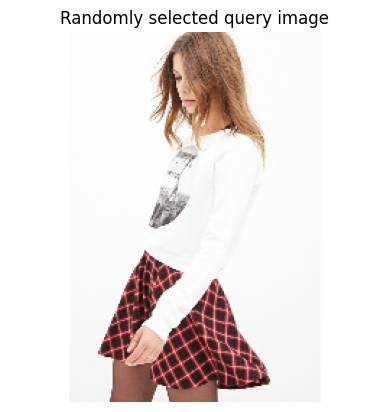

  [1]  dress                           confidence=0.849
  [2]  skirt                           confidence=0.583
  [3]  top, t-shirt, sweatshirt        confidence=0.385
  [4]  top, t-shirt, sweatshirt        confidence=0.265


/tmp/ipykernel_102/354534941.py:55: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(valid_dets))


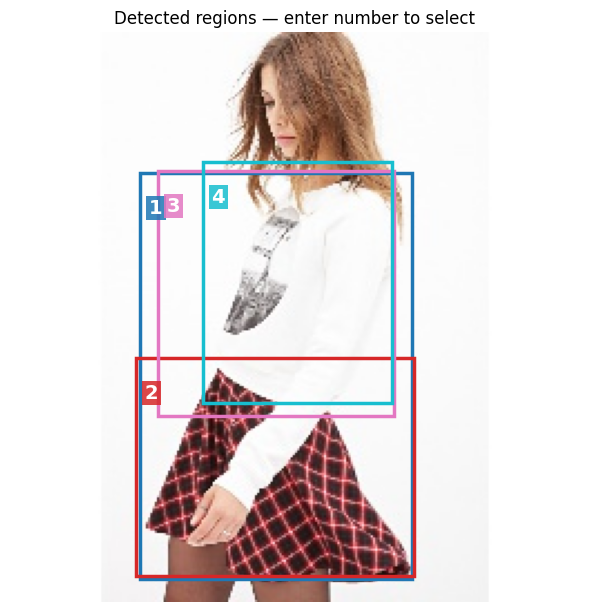


Enter box number (1-4), or 0 for full image:


Your choice:  1


Selected box 1: 'dress' (conf=0.849)


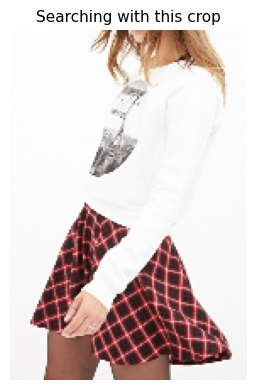

In [19]:
# ── CELL 2: PICK RANDOM IMAGE + YOLO CROP SELECTION ──────────────────────────
TOP_K = int(input("Enter TOP-K (e.g. 5, 10, 15): ").strip())
print(f"Retrieving top {TOP_K} results.\n")

# ── Pick random query ─────────────────────────────────────────────────────────
row      = query_df.sample(n=1).iloc[0]
img_path = str(IMG_ROOT_QUERY / row['image_name'])
true_id  = row['item_id']
image    = Image.open(img_path).convert('RGB')

print("=" * 60)
print(f"Query image : {row['image_name']}")
print(f"True item_id: {true_id}")
print("=" * 60)

plt.figure(figsize=(4, 5))
plt.imshow(image)
plt.title("Randomly selected query image", fontsize=12)
plt.axis('off')
plt.tight_layout()
plt.show()

# ── YOLO detection ────────────────────────────────────────────────────────────
img_w, img_h = image.size
inputs_yolo  = yolo_processor(images=image, return_tensors="pt").to(DEVICE)
with torch.no_grad():
    outputs_yolo = yolo_model_det(**inputs_yolo)

target_sizes = torch.tensor([[img_h, img_w]]).to(DEVICE)
det_results  = yolo_processor.post_process_object_detection(
    outputs_yolo, threshold=CONF_THRESHOLD, target_sizes=target_sizes
)[0]

valid_dets = []
for score, label, box in zip(det_results["scores"], det_results["labels"], det_results["boxes"]):
    label_name = yolo_model_det.config.id2label.get(label.item(), "")
    if label_name not in FASHION_CATEGORIES:
        continue
    x1, y1, x2, y2 = map(int, box.tolist())
    bw, bh = x2 - x1, y2 - y1
    if (bw / img_w) < MIN_BBOX_RATIO or (bh / img_h) < MIN_BBOX_RATIO:
        continue
    valid_dets.append({'score': score.item(), 'box': (x1, y1, x2, y2), 'label': label_name})

valid_dets.sort(key=lambda x: x['score'], reverse=True)

if not valid_dets:
    print("No fashion detections — using full image.")
    cropped_image = image
else:
    fig, ax = plt.subplots(1, 1, figsize=(6, 7))
    ax.imshow(image)
    ax.axis('off')
    ax.set_title("Detected regions — enter number to select", fontsize=12)
    colors = plt.cm.get_cmap('tab10', len(valid_dets))
    for i, det in enumerate(valid_dets):
        x1, y1, x2, y2 = det['box']
        color = colors(i)
        ax.add_patch(patches.Rectangle(
            (x1, y1), x2 - x1, y2 - y1,
            linewidth=2.5, edgecolor=color, facecolor='none'
        ))
        ax.text(
            x1 + 4, y1 + 18, str(i + 1),
            color='white', fontsize=14, fontweight='bold',
            bbox=dict(facecolor=color, alpha=0.85, pad=2, edgecolor='none')
        )
        print(f"  [{i+1}]  {det['label']:<30}  confidence={det['score']:.3f}")
    plt.tight_layout()
    plt.show()

    print(f"\nEnter box number (1-{len(valid_dets)}), or 0 for full image:")
    try:
        choice = int(input("Your choice: ").strip())
    except ValueError:
        choice = 0

    if 1 <= choice <= len(valid_dets):
        selected = valid_dets[choice - 1]
        x1, y1, x2, y2 = selected['box']
        pad_w = int((x2 - x1) * PADDING)
        pad_h = int((y2 - y1) * PADDING)
        x1 = max(0,     x1 - pad_w)
        y1 = max(0,     y1 - pad_h)
        x2 = min(img_w, x2 + pad_w)
        y2 = min(img_h, y2 + pad_h)
        cropped_image = image.crop((x1, y1, x2, y2))
        print(f"Selected box {choice}: '{selected['label']}' (conf={selected['score']:.3f})")
    else:
        cropped_image = image
        print("Using full image.")

    plt.figure(figsize=(3, 4))
    plt.imshow(cropped_image)
    plt.title("Searching with this crop", fontsize=11)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

Before reranking — Top-15 by CLIP similarity:


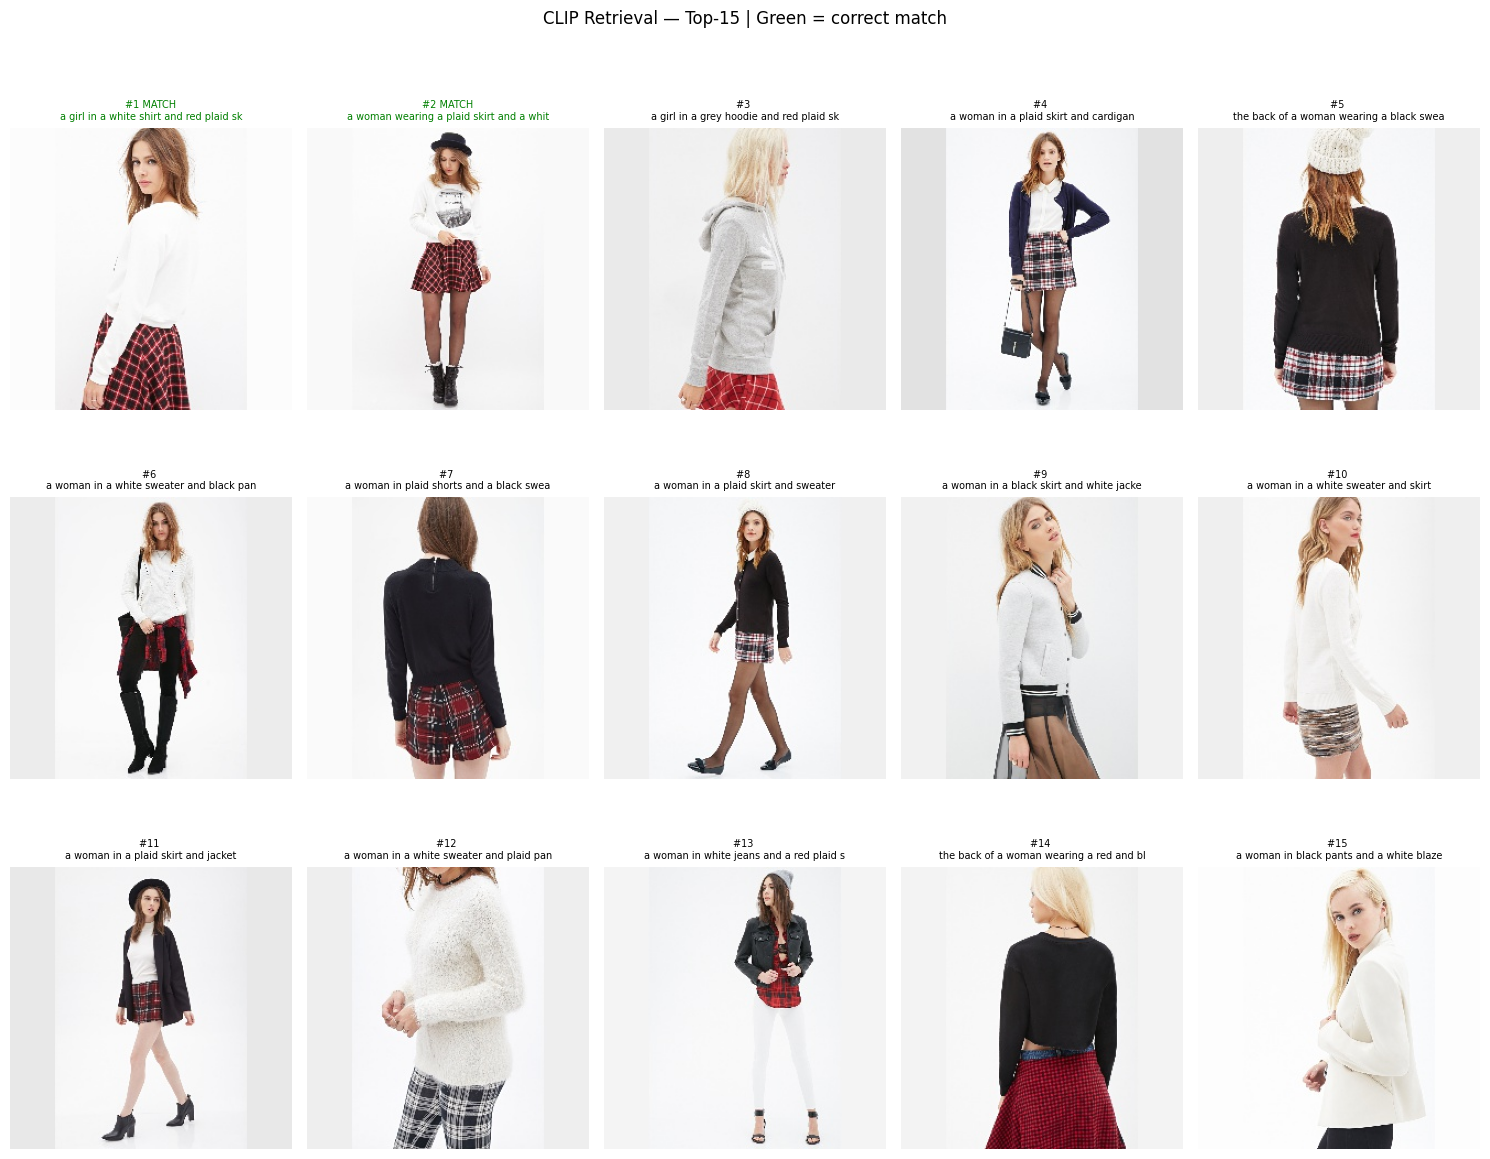

Reranking with BLIP ITM...


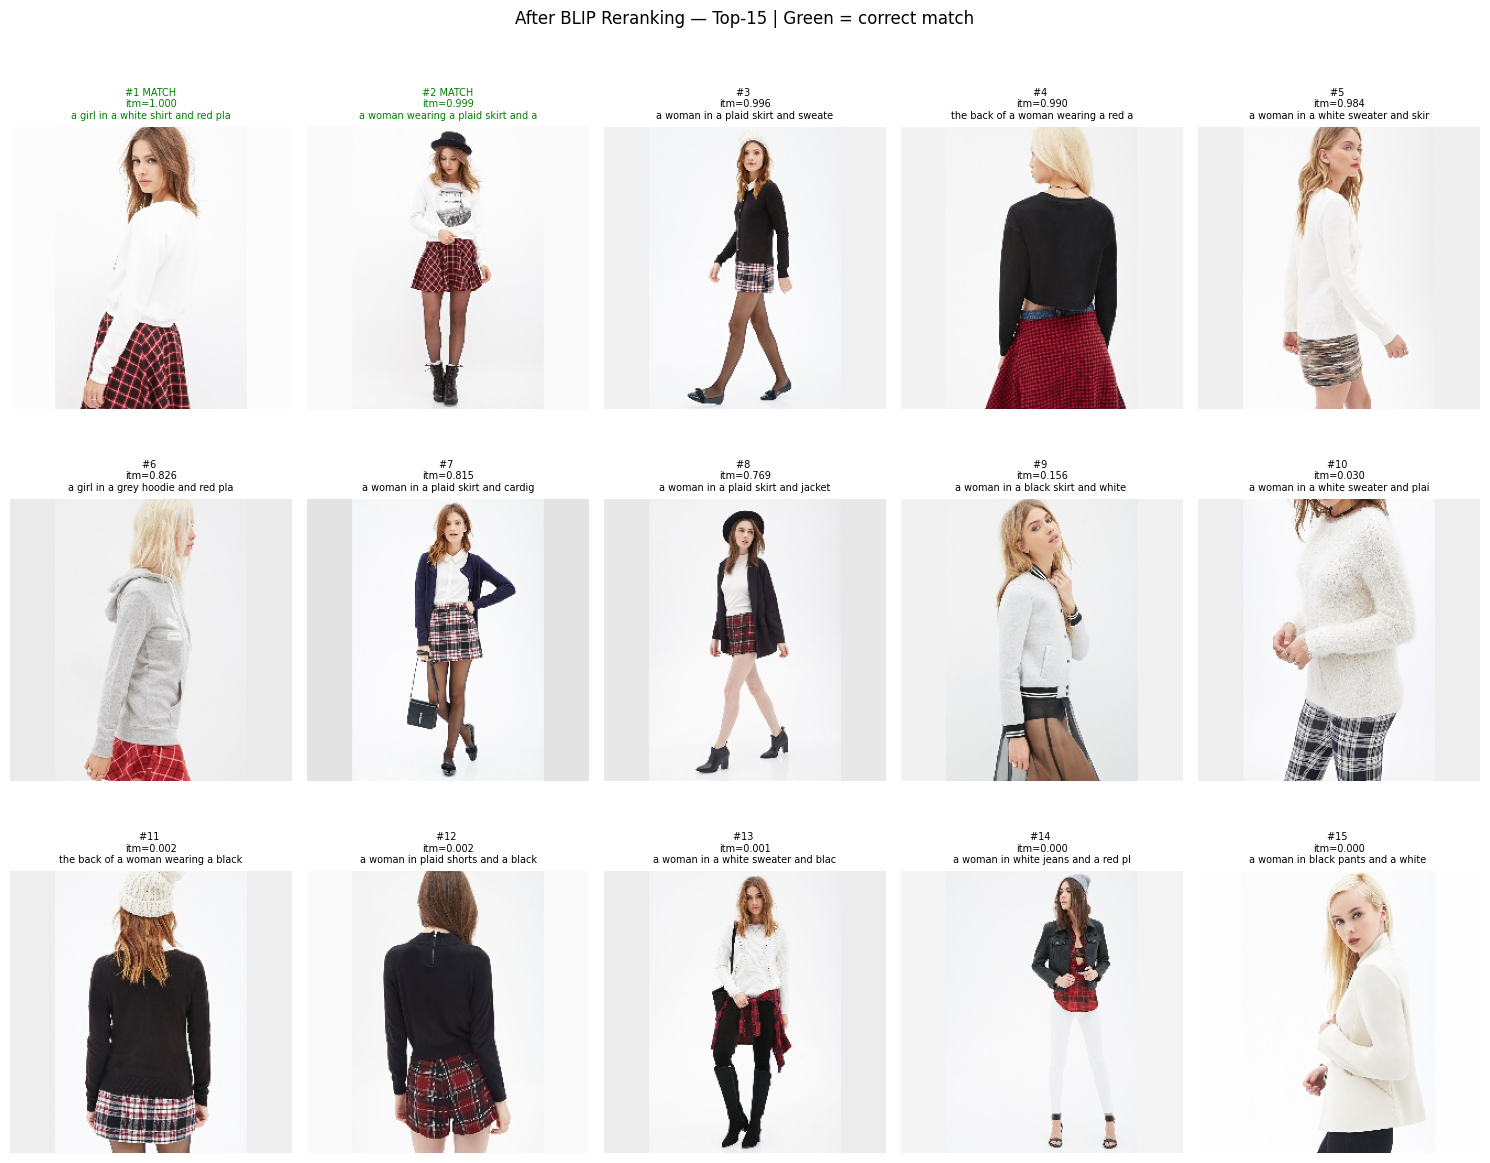

In [20]:
# ── CELL 3: RETRIEVAL + RERANKING + DISPLAY ───────────────────────────────────

# ── CLIP embed → HNSW retrieval ───────────────────────────────────────────────
with torch.no_grad():
    q_tensor = clip_preprocess(cropped_image).unsqueeze(0).to(DEVICE)
    q_emb    = F.normalize(clip_model.encode_image(q_tensor), dim=-1)
    q_emb    = q_emb.cpu().float().numpy()

q_emb = q_emb / np.linalg.norm(q_emb)
labels_out, distances = index.knn_query(q_emb, k=TOP_K)
retrieved_meta = [gallery_meta_loaded[i] for i in labels_out[0]]
clip_dists     = distances[0]

# ── Before reranking ──────────────────────────────────────────────────────────
print(f"Before reranking — Top-{TOP_K} by CLIP similarity:")
cols = 5
rows = (TOP_K + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 4))
axes = axes.flatten()

for i, (meta, dist) in enumerate(zip(retrieved_meta, clip_dists)):
    ax       = axes[i]
    cand_img = Image.open(str(IMG_ROOT_GALLERY / meta['image_name'])).convert('RGB')
    is_match = meta['item_id'] == true_id
    img_key  = "img/img/" + meta['image_name'].split("img/img/")[-1] if "img/img/" in meta['image_name'] else meta['image_name']
    caption  = normalized_captions.get(img_key, "fashion clothing")
    ax.imshow(cand_img)
    ax.axis('off')
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(4)
        spine.set_edgecolor('green' if is_match else 'red')
    ax.set_title(
        f"#{i+1} {'MATCH' if is_match else ''}\n{caption[:40]}",
        fontsize=7, color='green' if is_match else 'black'
    )

for j in range(TOP_K, len(axes)):
    axes[j].axis('off')
plt.suptitle(f"CLIP Retrieval — Top-{TOP_K} | Green = correct match", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

# ── BLIP reranking ────────────────────────────────────────────────────────────
print("Reranking with BLIP ITM...")
reranked = rerank_candidates(cropped_image, retrieved_meta)

fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 4))
axes = axes.flatten()

for i, (meta, itm_score) in enumerate(reranked):
    ax       = axes[i]
    cand_img = Image.open(str(IMG_ROOT_GALLERY / meta['image_name'])).convert('RGB')
    is_match = meta['item_id'] == true_id
    img_key  = "img/img/" + meta['image_name'].split("img/img/")[-1] if "img/img/" in meta['image_name'] else meta['image_name']
    caption  = normalized_captions.get(img_key, "fashion clothing")
    ax.imshow(cand_img)
    ax.axis('off')
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(4)
        spine.set_edgecolor('green' if is_match else 'red')
    ax.set_title(
        f"#{i+1} {'MATCH' if is_match else ''}\nitm={itm_score:.3f}\n{caption[:35]}",
        fontsize=7, color='green' if is_match else 'black'
    )

for j in range(TOP_K, len(axes)):
    axes[j].axis('off')
plt.suptitle(f"After BLIP Reranking — Top-{TOP_K} | Green = correct match", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()